In [1]:
import matplotlib.pyplot as plt
from netCDF4 import Dataset

import sys

import MaNTA

In [ ]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import jax
import jax.numpy as jnp

import jax.scipy.special as sci
import jax.scipy.integrate as integrate

from functools import partial

from jax.flatten_util import ravel_pytree

vmap_axes_adj = (None, {"Variable": 0, "Derivative": 0, "Flux": 0, "Aux": 0, "Scalars": None}, 0, None,  0)

class JAXAdjointProblem(MaNTA.AdjointProblem):
    def __init__(self, transport_system: MaNTA.TransportSystem, g):
        MaNTA.AdjointProblem.__init__(self)
        self.params = transport_system.params
        self.g = g

        self.ng = 1
        self.np = len(transport_system.params)
        # print(self.np_cell)
        self.npoints = len(transport_system.points)
        # self.np = self.np_cell * self.npoints
        self.np_boundary = 0
        self.spatialParameters = True
        self.sigma = transport_system.sigma
        self.source = transport_system.source

        self.daux_dp = jax.jit(jax.grad(transport_system.aux, argnums=4))

        self.UpperBoundarySensitivities = {}
        self.LowerBoundarySensitivities = {}

    def setParams(self, params):
        self.params = params

    def gFn(self, i, state, x):
        return self.g(state, x, self.params)

    #@partial(jax.jit, static_argnums=(0,1))
    def dgFndp(self, gIndex, states, positions):
        x = jnp.array(positions)
        dgdp = jax.vmap(jax.grad(self.g, argnums=2), in_axes=({"Variable": 0, "Derivative": 0, "Flux": 0, "Aux": 0, "Scalars": None}, 0, 0))(states, x, self.params)
        g, _ = ravel_pytree(dgdp)
        g = jnp.reshape(g, (self.np - self.np_boundary, len(positions)))

        out = jnp.pad(g, pad_width=(0, self.np_boundary), mode='constant', constant_values=0)
        return out.transpose()

    @partial(jax.jit, static_argnums=(0,))
    def dg(self, i, states, positions):
        x = jnp.array(positions)

        out = jax.vmap(jax.grad(self.g, argnums=0), in_axes=({"Variable": 0, "Derivative": 0, "Flux": 0, "Aux": 0, "Scalars": None}, 0, 0))(states, x, self.params)  
        out["Scalars"] = []
        return out

    #@partial(jax.jit, static_argnums=(0,))
    def dSigma(self, i, states, positions):
        x = jnp.array(positions)
        grad = jax.vmap(jax.grad(self.sigma, argnums=4), in_axes=(vmap_axes_adj))(i, states, x, 0.0, self.params)  
        grad_flattened, _ = jax.flatten_util.ravel_pytree(grad)
        grad_flattened = jnp.expand_dims(grad_flattened, 1)
        out = jnp.reshape(grad_flattened, (self.np, self.npoints ))
        return out
    
    
    @partial(jax.jit, static_argnums=(0,))
    def dSources(self, i, states, positions):
        x = jnp.array(positions)
        grad = jax.vmap(jax.grad(self.source, argnums=4), in_axes=(vmap_axes_adj))(i, states, x, 0.0, self.params)  
        grad_flattened, _ = jax.flatten_util.ravel_pytree(grad)
        grad_flattened = jnp.expand_dims(grad_flattened, 1)
        out = jnp.reshape(grad_flattened, (self.np, self.npoints ))
        return out

    @partial(jax.jit, static_argnums=(0,))
    def dgFn_dphi(self, i, state, x):
        return jax.grad(self.g, argnums=0)(state, x, self.params)["Aux"]
   
    def dAux_dp(self, index, pIndex, state, x):
        return self.daux_dp(index, state, x, 0.0, self.params )[pIndex]
    
    def computeUpperBoundarySensitivity(self, i, pIndex):
        if (i, pIndex) in self.UpperBoundarySensitivities:
            return True
        else:
            return False
        
    def computeLowerBoundarySensitivity(self, i, pIndex):
        if (i, pIndex) in self.LowerBoundarySensitivities:
            return True
        else:
            return False
    
    def getName(self, pIndex):
        if pIndex < len(self.params):
            return list(self.params._fields)[pIndex]
        else:
            return "BoundaryCondition"+str(pIndex)
        
    def addUpperBoundarySensitivity(self, i):
        self.UpperBoundarySensitivities[(i,self.np)] = True
        self.np += 1
        self.np_boundary += 1

    def addLowerBoundarySensitivity(self, i):
        self.LowerBoundarySensitivities[(i,self.np)] = True
        self.np += 1
        self.np_boundary += 1
    
   

In [3]:
from typing import NamedTuple
from VectorizedTransportSystem import VectorizedTransportSystem

vmap_axes = ({"Variable": 0, "Derivative": 0, "Flux": 0, "Aux": 0, "Scalars": None}, 0, 0)

class JAXNonlinearDiffusion(VectorizedTransportSystem):
    def __init__(self, kappa):
        super().__init__()
        self.nVars = 1
        self.isUpperDirichlet  = True
        self.isLowerDirichlet  = False
        
        self.T_s = 50.0
        self.SourceWidth = 0.02
        self.SourceCentre = 0.3

        config = {
            "OutputFilename": "out",
            "Polynomial_degree": 4,
            "Grid_size": 20,
            "tau": 1.0, 
            "Lower_boundary": 0.0,
            "Upper_boundary": 1.0,
            "Relative_tolerance": 0.01,
            "delta_t": 0.01,
            "restart": False,
            "solveAdjoint": True, 
        }

        self.points = MaNTA.getNodes(config["Lower_boundary"], config["Upper_boundary"], config["Grid_size"], config["Polynomial_degree"])

        self.D = lambda x, kappa : (x + 1) * kappa

        self.params = {
            "D": self.D(self.points, kappa),
            "T_s": self.T_s * jnp.ones(len(self.points)),
            "a": 2.0 * jnp.ones(len(self.points)),
            "SourceWidth": self.SourceWidth * jnp.ones(len(self.points)),
            "SourceCentre": self.SourceCentre * jnp.ones(len(self.points))
        }
        self.runner = MaNTA.Runner(self)

        self.runner.configure(config)

        self.adjointProblem = JAXAdjointProblem(self, self.g)
        self.runner.setAdjointProblem(self.adjointProblem)
        # This object will be passed to sigma and source functions
    
    def run(self, tFinal = None, kappa = None):
        if (kappa is not None):
            self.params["D"] = self.D(self.points, kappa)
        
        if (tFinal is not None):
            sFinal = self.runner.run(tFinal)
        else: 
            sFinal = self.runner.run_ss()

        return sFinal

    def runAdjointSolve(self, kappa = None):
        if (kappa is not None):
            self.params["D"] = self.D(self.points, kappa)
        G, G_p = self.runner.runAdjointSolve()
        return G, G_p

    def g(self, state, x, params):
        u = state["Variable"][0]
        return 0.5 * u * u * params["D"]

         
    def SigmaFn( self, index, state, x, t ):
        u = state["Variable"][0]
        q = state["Derivative"][0]
        return self.D(x, 4.0)*(u ** 2.0) * q

    def Sources(self, index, state, x, t):
        y = x - self.SourceCentre
        return self.T_s*jnp.exp(-y*y/self.SourceWidth)

    def SigmaFn_v( self, index, states, positions, t):
        x = jnp.array(positions)
        return jax.vmap(lambda s, p, params : self.sigma(index, s, p, t, params), in_axes=(vmap_axes))(states, x, self.params)

    #@partial(jax.jit, static_argnums=(0,))
    def Sources_v( self, index, states, positions, t ):
        x = jnp.array(positions)
        return jax.vmap(lambda s, p, params : self.source(index, s, p, t, params), in_axes=(vmap_axes))(states, x, self.params)
        
    #@partial(jax.jit, static_argnums=(0,))
    def dSigma(self, index, states, positions, t):
        x = jnp.array(positions)
        out =  jax.vmap(lambda s, p, params: jax.grad(self.sigma, argnums=1)(index, s, p, t, params), in_axes=(vmap_axes))(states, x, self.params)
        out["Scalars"] = []
        return out
    
    #@partial(jax.jit, static_argnums=(0,))
    def dSources(self, index, states, positions, t):
        x = jnp.array(positions)
        out =  jax.vmap(lambda s, p, params: jax.grad(self.source, argnums=1)(index, s, p, t, params), in_axes=(vmap_axes))(states, x, self.params)
        out["Scalars"] = []
        return out
    
    def sigma( self, index, state, x, t, params ):
        
        u = state["Variable"][0]
        q = state["Derivative"][0]
        return params["D"]*(u ** params["a"]) * q

    def source( self, index, state, x, t, params ):
        y = x - params["SourceCentre"]
        return params["T_s"]*jnp.exp(-y*y/params["SourceWidth"])


    def LowerBoundary(self, index, t):
        return 0.0

    def UpperBoundary(self, index, t):
        return 0.3
    
    def InitialValue(self, index, x):
        return 0.3
    
    def createAdjointProblem(self):
        pass

In [4]:
nl = JAXNonlinearDiffusion(4.0)
nl.run(tFinal = 5.0)

INFO: Using default value for configuration option High_Grid_Boundary
INFO: Using default value for configuration option Lower_Boundary_Fraction
INFO: Using default value for configuration option Upper_Boundary_Fraction
INFO: Creating grid with 20 cells from x = 0 to x = 1
Total HDG degrees of freedom 321
INFO: Using default value for configuration option Absolute_tolerance
INFO: Using default value for configuration option tZero
INFO: Using default value for configuration option MinStepSize
INFO: Using default value for configuration option OutputPoints
INFO: Using default value for configuration option SteadyStateTolerance
INFO: Using default value for configuration option WriteOutput
Setting initial conditions
Configuration done.


Writing output at 0.01 ( 15 timesteps )
Writing output at 0.02 ( 23 timesteps )
Writing output at 0.03 ( 30 timesteps )
Writing output at 0.04 ( 34 timesteps )
Writing output at 0.05 ( 38 timesteps )
Writing output at 0.06 ( 42 timesteps )
Writing output at 0.07 ( 44 timesteps )
Writing output at 0.08 ( 45 timesteps )
Writing output at 0.09 ( 46 timesteps )
Writing output at 0.1 ( 47 timesteps )
Writing output at 0.11 ( 49 timesteps )
Writing output at 0.12 ( 50 timesteps )
Writing output at 0.13 ( 51 timesteps )
Writing output at 0.14 ( 51 timesteps )
Writing output at 0.15 ( 52 timesteps )
Writing output at 0.16 ( 53 timesteps )
Writing output at 0.17 ( 53 timesteps )
Writing output at 0.18 ( 54 timesteps )
Writing output at 0.19 ( 54 timesteps )
Writing output at 0.2 ( 55 timesteps )
Writing output at 0.21 ( 56 timesteps )
Writing output at 0.22 ( 56 timesteps )
Writing output at 0.23 ( 56 timesteps )
Writing output at 0.24 ( 56 timesteps )
Writing output at 0.25 ( 57 timesteps )
Wr

In [5]:
import numpy as np
from netCDF4 import Dataset

data = Dataset("./out.nc")
print(data)

Vars = data.groups
Grid = jnp.array(np.array(data.groups["Grid"].variables["CellBoundaries"]))
t = jnp.array(np.array(data.variables["t"]))
x = jnp.array(np.array(data.variables["x"]))
u = jnp.array(np.array(Vars["Var0"].variables["u"]))
data.close()

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): t(501), x(301)
    variables(dimensions): float64 t(t), float64 x(x), float64 nVariables()
    groups: Grid, Var0


/tmp/ipykernel_609603/1584926321.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  Grid = jnp.array(np.array(data.groups["Grid"].variables["CellBoundaries"]))
/tmp/ipykernel_609603/1584926321.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  t = jnp.array(np.array(data.variables["t"]))
/tmp/ipykernel_609603/1584926321.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'cop

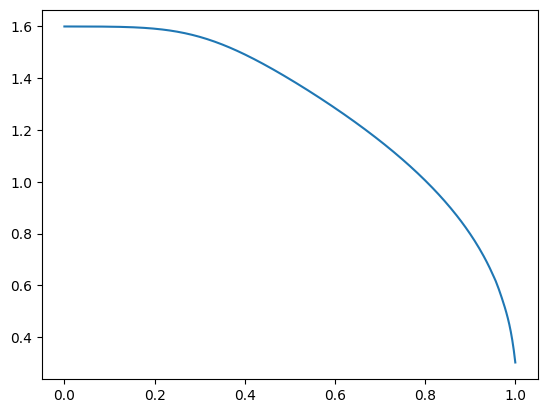

In [6]:
fig,ax = plt.subplots()
ax.plot(x,u[-1,:])

In [7]:
nl.runAdjointSolve()

Computing adjoints


INFO: Computing adjoints for 5 parameters


[[-1.68306287e-04 -1.65193330e-03 -4.97766910e-03 -9.85011552e-03
  -1.38831642e-02 -1.51296221e-02 -2.04337593e-02 -3.16915065e-02
  -4.70962450e-02 -5.91599979e-02 -6.27874956e-02 -7.77918845e-02
  -1.07806526e-01 -1.46011546e-01 -1.74248144e-01 -1.82503223e-01
  -2.15663224e-01 -2.78124720e-01 -3.51993412e-01 -4.03460234e-01
  -4.18083191e-01 -4.75109607e-01 -5.76207221e-01 -6.87179983e-01
  -7.59980381e-01 -7.80069709e-01 -8.56104255e-01 -9.82849598e-01
  -1.11175072e+00 -1.19120777e+00 -1.21247721e+00 -1.29053688e+00
  -1.41259122e+00 -1.52711201e+00 -1.59312904e+00 -1.61022270e+00
  -1.67089188e+00 -1.75924551e+00 -1.83478343e+00 -1.87492800e+00
  -1.88489413e+00 -1.91876984e+00 -1.96352303e+00 -1.99666047e+00
  -2.01184559e+00 -2.01529551e+00 -2.02588296e+00 -2.03629422e+00
  -2.03964210e+00 -2.03877878e+00 -2.03821278e+00 -2.03501630e+00
  -2.02672005e+00 -2.01543236e+00 -2.00733423e+00 -2.00503421e+00
  -1.99613190e+00 -1.98077095e+00 -1.96462119e+00 -1.95439970e+00
  -1.95162

RuntimeError: Unable to cast Python instance of type <class 'numpy.ndarray'> to C++ type 'double'